In [ ]:
# --- MACHINE LEARNING SOLUTION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

import lightgbm as lgb
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier # Use a fast estimator for selection
from imblearn.combine import SMOTEENN

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, make_scorer)
from imblearn.over_sampling import SMOTE, ADASYN

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import QuantileTransformer

import xgboost as xgb

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.compose import ColumnTransformer
import joblib
import warnings
warnings.filterwarnings('ignore')

In [81]:
# ======================
#  DATA LOADING
# ======================
print("Loading data...")
df = pd.read_csv('data.csv')

# Convert target variable
df['OBJ'] = df['OBJ'].map({'NO': 0, 'SI': 1})

# Handle missing values
print("\nHandling missing values...")
df.fillna(df.median(numeric_only=True), inplace=True)

Loading data...

Handling missing values...


In [82]:
# ======================
#  DATA PREPROCESSING
# ======================

# Efficient cross-feature and binarized flag generation using preallocation
cross_features = {}
binarized_flags = {}

for i in range(1, 31):
    for j in range(i + 1, 31):
        cross_features[f'V{i}_x_V{j}'] = df[f'V{i}'] * df[f'V{j}']
    binarized_flags[f'V{i}_gt_mean'] = (df[f'V{i}'] > df[f'V{i}'].mean()).astype(int)

# Concatenate all new features at once
df = pd.concat([df, pd.DataFrame(cross_features), pd.DataFrame(binarized_flags)], axis=1)
df = df.copy()  # Defragment to avoid future warnings

# Target and features
y = df['OBJ']
X = df.drop(columns=['OBJ'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# ======================
#  MODEL PIPELINES
# ======================

# Pipeline RF
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Calculate the scale_pos_weight for XGBoost. This is the most efficient
# way to handle class imbalance and is the direct equivalent of 'class_weight=balanced'.
# The formula is: count(negative_class) / count(positive_class)
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight_value:.2f}")

# XGBoost pipeline (includes the required StandardScaler)
pipe_xgb = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight_value, # Use the calculated weight
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False # To suppress a potential warning
    ))
])


Calculated scale_pos_weight for XGBoost: 2.82


In [84]:
# ======================
#  HYPERPARAMETER GRIDS
# ======================

# Grid RF
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10],
    'clf__min_samples_split': [2, 5]
}

# Grid XGB
# It focuses on the most impactful parameters to keep training time low.
param_grid_xgb = {
    'clf__n_estimators': [100, 200],         # How many trees to build.
    'clf__max_depth': [3, 5, 7],            # Controls tree complexity. Start with smaller values.
    'clf__learning_rate': [0.05, 0.1, 0.2],  # How quickly the model learns.
    'clf__subsample': [0.7, 0.8],           # Fraction of samples used for each tree (prevents overfitting).
    'clf__colsample_bytree': [0.7, 0.8]     # Fraction of features used for each tree.
}

In [ ]:
# ======================
#  MODEL TRAINING
# ======================
models = {
    'Random_Forest': (pipe_rf, param_grid_rf),
    'XGBoost': (pipe_xgb, param_grid_xgb)
}

best_models = {}
results = []

print("\n=== MODEL TRAINING ===")
for name, (pipe, params) in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    print(f"{'='*40}")

    try:
        # Grid Search with error handling
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=params,
            scoring='f1',
            cv=5,
            n_jobs=-1,
            verbose=2,
            error_score='raise'  # Get detailed errors
        )
        gs.fit(X_train, y_train)

        # Store best model
        best_models[name] = gs.best_estimator_

        # Predictions
        y_pred = gs.predict(X_test)
        y_proba = gs.predict_proba(X_test)[:, 1]

        # Metrics
        metrics = {
            'Model': name,
            'Best Params': gs.best_params_,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba)
        }
        results.append(metrics)

        print(f"\n{name} Best Parameters: {gs.best_params_}")
        print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")
        print(f"Test Recall: {metrics['Recall']:.4f}")

    except Exception as e:
        print(f"\nERROR in {name}: {str(e)}")
        print("Trying fallback configuration...")

        # Fallback to default model without grid search
        try:
            pipe.set_params(**{k.split('__')[1]: v for k, v in params[0].items()} if isinstance(params, list) else {k.split('__')[1]: v for k, v in params.items()})
            pipe.fit(X_train, y_train)

            y_pred = pipe.predict(X_test)
            y_proba = pipe.predict_proba(X_test)[:, 1]

            metrics = {
                'Model': name + '_Fallback',
                'Best Params': 'Default',
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred),
                'F1-Score': f1_score(y_test, y_pred),
                'ROC-AUC': roc_auc_score(y_test, y_proba)
            }
            results.append(metrics)

            print(f"Fallback {name} Performance:")
            print(f"Test ROC-AUC: {metrics['ROC-AUC']:.4f}")

        except Exception as fallback_e:
            print(f"Fallback failed: {str(fallback_e)}")
            continue


=== MODEL TRAINING ===

Training Random_Forest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Random_Forest Best Parameters: {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Test ROC-AUC: 0.6207
Test Recall: 0.5134

Training XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

XGBoost Best Parameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Test ROC-AUC: 0.6306
Test Recall: 0.5687



=== MODEL COMPARISON ===
           Model                                        Best Params  Accuracy  \
1        XGBoost  {'clf__colsample_bytree': 0.8, 'clf__learning_...     0.614   
0  Random_Forest  {'clf__max_depth': 5, 'clf__min_samples_split'...     0.639   

   Precision    Recall  F1-Score   ROC-AUC  
1   0.353081  0.568702  0.435673  0.630611  
0   0.365489  0.513359  0.426984  0.620709  

Best Model: XGBoost (ROC-AUC: 0.6306)

Optimal threshold: 0.4106 (default=0.5)

Optimized Performance:
Accuracy: 0.4660
Precision: 0.3038
Recall: 0.8034
F1-Score: 0.4408


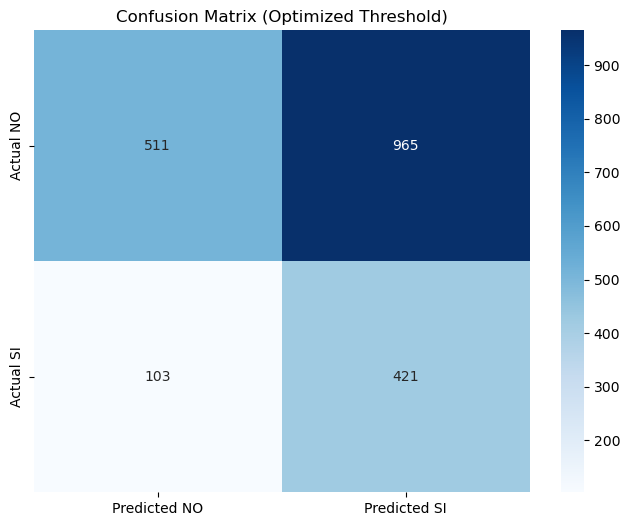


Saved best model as 'best_model.pkl'


In [86]:
# ======================
#  RESULTS ANALYSIS
# ======================
if results:
    results_df = pd.DataFrame(results)
    print("\n=== MODEL COMPARISON ===")
    print(results_df.sort_values('ROC-AUC', ascending=False))

    # Select best model
    best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    best_model = best_models[best_model_name]
    print(f"\nBest Model: {best_model_name} (ROC-AUC: {results_df['ROC-AUC'].max():.4f})")

    # Threshold optimization
    y_proba = best_model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"\nOptimal threshold: {best_threshold:.4f} (default=0.5)")
    y_pred_opt = (y_proba >= best_threshold).astype(int)

    print("\nOptimized Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_opt):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_opt)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted NO', 'Predicted SI'],
                yticklabels=['Actual NO', 'Actual SI'])
    plt.title('Confusion Matrix (Optimized Threshold)')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Save best model
    joblib.dump(best_model, 'best_model.pkl')
    print("\nSaved best model as 'best_model.pkl'")
else:
    print("\nNo models trained successfully")

In [87]:
# =======================================================
#  PHASE 4: DEEP ERROR ANALYSIS
#  Goal: Understand *why* the best model is making mistakes.
# =======================================================

print("--- Starting Deep Error Analysis ---")

# --- Step 1: Prepare Data and Define Best Pipeline ---
# Ensure you are using the same data and splits as before for consistency.

# Load data
data = pd.read_csv('data.csv')
data['OBJ'] = data['OBJ'].map({'NO': 0, 'SI': 1})
X = data.drop('OBJ', axis=1)
y = data['OBJ']

# Split data with the same random_state used in your notebook
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Define your best pipeline from Step 3 (LightGBM + RFECV + SMOTEENN)
# This is based on the final pipeline in your notebook
best_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('feature_selection', RFECV(estimator=DecisionTreeClassifier(random_state=42), step=1, cv=3, scoring='f1', min_features_to_select=15)),
    ('resample', SMOTEENN(random_state=42)),
    ('clf', lgb.LGBMClassifier(random_state=42))
])


# --- Step 2: Train the Model and Get Predictions ---
print("\nTraining the best model on the full training data...")
best_pipeline.fit(X_train, y_train)

print("Making predictions on the test set...")
y_pred_test = best_pipeline.predict(X_test)


# --- Step 3: Create an Analysis DataFrame ---
# This dataframe combines test features, true values, and predictions for easy filtering.
print("Creating analysis dataframe...")

# Create a copy to avoid SettingWithCopyWarning
X_test_analysis = X_test.copy()
X_test_analysis['true_label'] = y_test
X_test_analysis['predicted_label'] = y_pred_test

# Identify where the model was wrong
X_test_analysis['is_correct'] = (X_test_analysis['true_label'] == X_test_analysis['predicted_label'])

print(f"\nModel Accuracy on Test Set: {X_test_analysis['is_correct'].mean():.4f}")


# --- Step 4: Isolate and Analyze the Errors ---

# Isolate the different prediction outcomes
correctly_classified = X_test_analysis[X_test_analysis['is_correct'] == True]
misclassified = X_test_analysis[X_test_analysis['is_correct'] == False]
false_positives = X_test_analysis[(X_test_analysis['true_label'] == 0) & (X_test_analysis['predicted_label'] == 1)]
false_negatives = X_test_analysis[(X_test_analysis['true_label'] == 1) & (X_test_analysis['predicted_label'] == 0)]

print(f"\nTotal misclassified instances: {len(misclassified)}")
print(f"Number of False Positives (Predicted 1, Actually 0): {len(false_positives)}")
print(f"Number of False Negatives (Predicted 0, Actually 1): {len(false_negatives)}")


# --- Step 5: Compare Statistical Summaries ---
# This is the core of the analysis. We compare the descriptive statistics
# of the error groups to the correctly classified group.

print("\n\n--- Statistical Summary: CORRECTLY Classified ---")
print(correctly_classified.describe().transpose())

if not false_positives.empty:
    print("\n\n--- Statistical Summary: FALSE POSITIVES ---")
    print(false_positives.describe().transpose())

if not false_negatives.empty:
    print("\n\n--- Statistical Summary: FALSE NEGATIVES ---")
    print(false_negatives.describe().transpose())

print("\n--- End of Deep Error Analysis ---")

--- Starting Deep Error Analysis ---

Training the best model on the full training data...
[LightGBM] [Info] Number of positive: 2422, number of negative: 1892
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10455
[LightGBM] [Info] Number of data points in the train set: 4314, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.561428 -> initscore=0.246959
[LightGBM] [Info] Start training from score 0.246959
Making predictions on the test set...
Creating analysis dataframe...

Model Accuracy on Test Set: 0.6050

Total misclassified instances: 790
Number of False Positives (Predicted 1, Actually 0): 521
Number of False Negatives (Predicted 0, Actually 1): 269


--- Statistical Summary: CORRECTLY Classified ---
                  count          mean           std           min  \
ALEAT            1210.0  2.998943e-02  1.69